# 03. Explainability and fairness

Global SHAP importance, per-student explanations, permutation importance, and a subgroup fairness audit of the at-risk model.

In [1]:
import sys, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Image, Markdown, display
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)

from edupulse.config import get_settings
S = get_settings()
print("EduPulse project root:", S.project_root)

EduPulse project root: C:\Users\WzA\Desktop\ZAIN\PAI


In [2]:
from edupulse.models.registry import ModelRegistry
from edupulse.models.explain import Explainer
from edupulse.pipeline import load_engineered
reg = ModelRegistry(S.models_dir)
m = reg.load('at_risk')
df = load_engineered(S)
X = df[m.task.features]
print(m.metadata.model_name, 'v' + m.metadata.version, '| threshold', round(m.threshold, 3))

04:02:00 | INFO     | edupulse.data.loader | Loaded raw dataset StudentsPerformance.csv with shape (1000, 8)


logistic_regression v20260911-223257 | threshold 0.416


## 1. Global importance (mean absolute SHAP, aggregated back to the original features)

In [3]:
ex = Explainer(m.pipeline, m.task, X, max_background=200)
gi = ex.global_importance(X.sample(300, random_state=0))
gi.plot.barh(x='feature', y='mean_abs_shap', legend=False, color='#4F46E5', figsize=(8,4)); plt.gca().invert_yaxis(); plt.title('Mean absolute SHAP');
gi

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


,feature,mean_abs_shap
0,lunch,0.600615
1,test_preparation_course,0.437894
2,race_ethnicity,0.308097
3,parental_level_of_education,0.277134
4,gender,0.269213


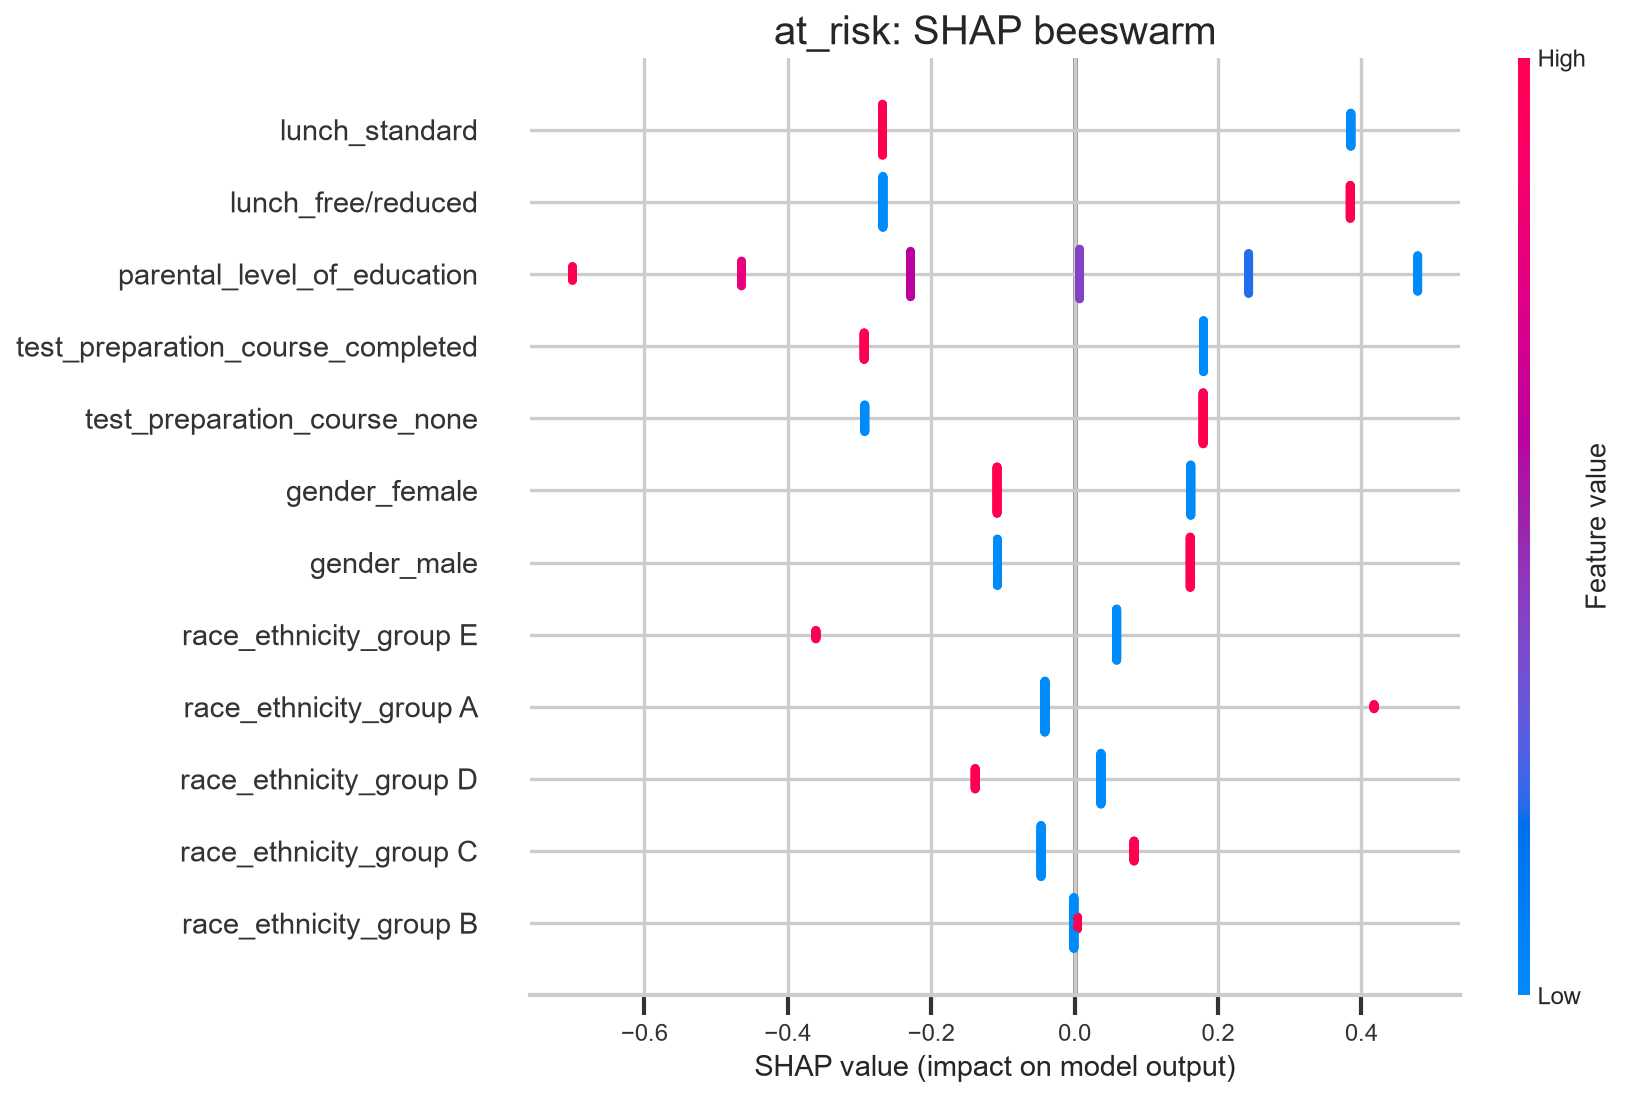

In [4]:
p = m.metadata.figures.get('shap_beeswarm')
if p and Path(p).exists(): display(Image(p, width=850))

## 2. Explain one student
Contributions are in log-odds for the linear model and in probability space for tree models. Positive values push towards at risk.

In [5]:
student = pd.DataFrame([{'gender':'male','race_ethnicity':'group A','parental_level_of_education':'high school','lunch':'free/reduced','test_preparation_course':'none'}])
proba = m.pipeline.predict_proba(student)[0, 1]
print(f'P(at risk) = {proba:.3f}  ->  flagged: {proba >= m.threshold}')
contrib = pd.DataFrame(ex.local_explanation(student, top_k=5))
contrib.plot.barh(x='feature', y='contribution', color=np.where(contrib.contribution > 0, '#EF4444', '#10B981'), legend=False, figsize=(8,3)); plt.gca().invert_yaxis();
contrib

P(at risk) = 0.885  ->  flagged: True


,feature,value,contribution
0,lunch,free/reduced,0.874175
1,race_ethnicity,group A,0.471180
2,test_preparation_course,none,0.368587
3,gender,male,0.274890
4,parental_level_of_education,high school,0.226309


## 3. Permutation importance (model-agnostic, hold-out)

In [6]:
pd.DataFrame(m.metadata.explainability['permutation_importance']).style.bar(subset=['importance_mean'], color='#A5B4FC').format(precision=4)

,feature,importance_mean,importance_std
0,test_preparation_course,0.0790,0.0248
1,lunch,0.0426,0.0233
2,parental_level_of_education,0.0269,0.0185
3,gender,0.0142,0.0141
4,race_ethnicity,0.0084,0.0085


## 4. Fairness audit
We slice hold-out performance by sensitive attributes. Because base rates genuinely differ between groups (for example, free/reduced-lunch students are at risk twice as often), some disparity in selection rate is expected. The metric to watch for an early-warning tool is the TPR gap (equal opportunity): are we equally good at catching at-risk students in every group?

In [7]:
fair = pd.DataFrame(m.metadata.fairness['groups'])
fair.style.format(precision=3).background_gradient(subset=['tpr'], cmap='Greens')

,attribute,group,n,prevalence,selection_rate,tpr,fpr,precision,roc_auc
0,gender,female,96,0.240,0.469,0.609,0.425,0.311,0.713
1,gender,male,104,0.327,0.731,0.824,0.686,0.368,0.672
2,race_ethnicity,group A,16,0.438,0.875,1.000,0.778,0.500,0.786
3,race_ethnicity,group B,40,0.350,0.625,0.643,0.615,0.360,0.507
4,race_ethnicity,group C,57,0.298,0.684,0.706,0.675,0.308,0.655
5,race_ethnicity,group D,58,0.241,0.586,0.857,0.500,0.353,0.772
6,race_ethnicity,group E,29,0.172,0.310,0.400,0.292,0.222,0.767
7,lunch,free/reduced,79,0.354,0.949,0.964,0.941,0.360,0.782
8,lunch,standard,121,0.240,0.380,0.517,0.337,0.326,0.687
9,parental_level_of_education,associate's degree,43,0.256,0.442,0.545,0.406,0.316,0.689


In [8]:
pd.DataFrame(m.metadata.fairness['summary']).T.style.format(precision=3)

,selection_rate_gap,tpr_gap,fpr_gap,precision_gap,disparate_impact_ratio
gender,0.262,0.215,0.261,0.057,0.641
lunch,0.569,0.447,0.604,0.034,0.400
parental_level_of_education,0.556,0.455,0.603,0.281,0.339
race_ethnicity,0.565,0.600,0.486,0.278,0.355


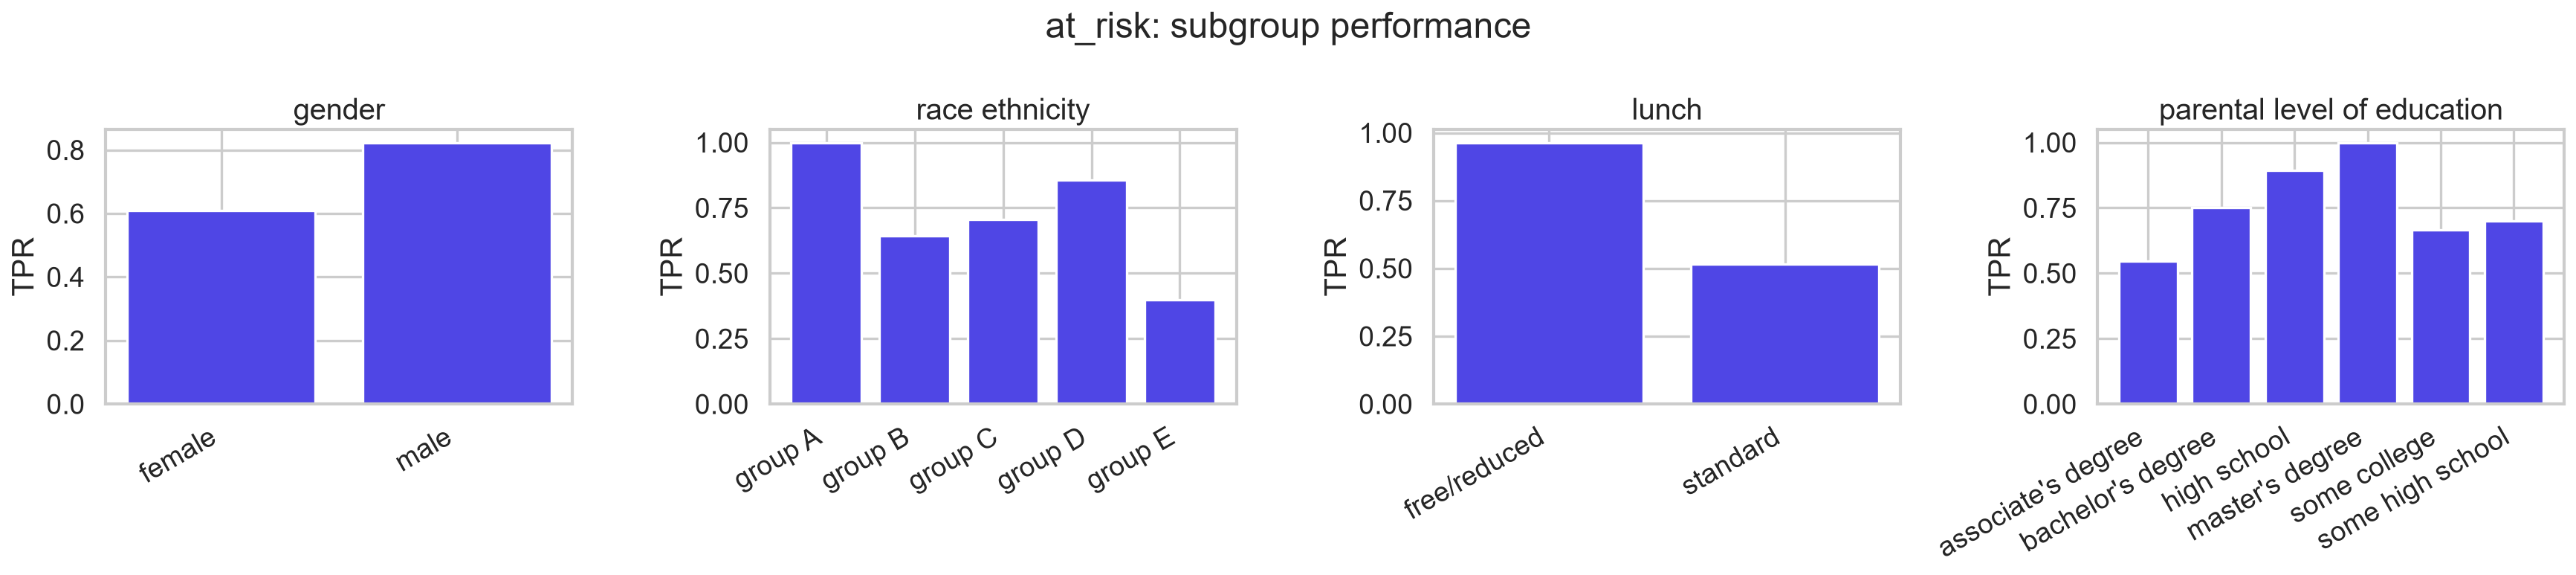

In [9]:
p = m.metadata.figures.get('fairness')
if p and Path(p).exists(): display(Image(p, width=900))

## Takeaways
* Income proxies (lunch, parental education) and test preparation dominate the risk score. Gender and ethnicity contribute less.
* The model is a triage tool. SHAP explanations make each flag auditable by an advisor.
* Group TPR gaps are recorded in the model card. Group-specific thresholds and reweighing are the next steps for mitigation.